In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!pip install wfdb

In [17]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.io import loadmat
import scipy.io
import json

from scipy.signal import resample
import wfdb


%matplotlib inline

---
# **_▞▞ Configuration ▞▞_**

All key hyperparameters in one place.

### Single-lead vs 12-lead
To use only **one lead**, set `N_LEADS = 1` and `LEAD_INDEX` to the lead you want:
- `0` = Lead I, `1` = Lead II, `2` = Lead III
- `3`–`5` = aVR, aVL, aVF
- `6`–`11` = V1–V6

Set `N_LEADS = 12` and `LEAD_INDEX = None` to use all leads.

---

In [18]:
# ============================================================
#  CONFIGURATION — change these to switch modes easily
# ============================================================

# Lead configuration
N_LEADS     = 12          # Number of input channels: 1 or 12
LEAD_INDEX  = None        # None = all leads; 0-11 = specific lead (only used if N_LEADS=1)
                          # Example for single lead II: N_LEADS=1, LEAD_INDEX=1

# Model architecture
FILTERS     = 32          # Conv1 filters
KSIZE       = 4           # Kernel size
OUTFEAT     = 4          # Number of arrhythmia classes

# Training
EPOCHS      = 10
BATCH_SIZE  = 32          #change the amount of data been train per epoch
LR          = 0.0001      # FIX: was 0.01, too high;
PATIENCE    = 5           # Early stopping patience (epochs without val improvement)
DROPOUT_P   = 0.6         # Dropout probability

# Data
RANDOMIZER  = 42
TESTSIZE    = 0.15
VALSIZE     = 0.15
SR_RATIO    = 1        # Keep only 50% of SR samples to reduce class imbalance

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
# **_▞▞ Load the data ▞▞_**
Loading the new, implemented data based from various datasets. Using Pandas, we're able to insert the information from our built-in dataset, `'model_colab_ready_dataset.csv'`.

Datasets implemented so far:

* Wagner, P., Strodthoff, N., Bousseljot, R., Samek, W., & Schaeffter, T. (2022). PTB-XL, a large publicly available electrocardiography dataset (version 1.0.3). PhysioNet. RRID:SCR_007345. https://doi.org/10.13026/kfzx-aw45


* Zheng, J., Guo, H., & Chu, H. (2022). A large scale 12-lead electrocardiogram database for arrhythmia study (version 1.0.0). PhysioNet. RRID:SCR_007345. https://doi.org/10.13026/wgex-er52
---

In [19]:
#final well destributed dataset
df_filtered = pd.read_csv('/content/drive/MyDrive/TESIS-V2/Data/balanced_dataset_v3.csv')

def get_primary_label(labels):
    priority = ['AFIB', 'STACH', 'SBRAD', 'SR']
    for p in priority:
        if p in labels:
            return p
    return labels[0] # Failsafe

df_filtered['primary_label'] = df_filtered['filtered_labels'].apply(get_primary_label)

# 6. Balance the dataset (Undersampling)
# Find the size of our smallest class (TWC in this case)
min_class_size = df_filtered['primary_label'].value_counts().min()
print(f"Balancing all classes to match the smallest class size: {min_class_size} records")

# Group by the primary label, and randomly sample exactly 'min_class_size' rows from each
df_balanced = df_filtered.groupby('primary_label').sample(n=min_class_size, random_state=RANDOMIZER).reset_index(drop=True)

# 7. Verification
print("\n--- FINAL BALANCED COUNTS ---")
print(df_balanced['primary_label'].value_counts())
print(f"\nFinal dataset ready for training: {len(df_balanced)} records")

Balancing all classes to match the smallest class size: 7329 records

--- FINAL BALANCED COUNTS ---
primary_label
AFIB     7329
SBRAD    7329
SR       7329
STACH    7329
Name: count, dtype: int64

Final dataset ready for training: 29316 records


In [20]:
#df_balanced.describe()

---

# **_▞▞ Working with the Dataset ▞▞_**

We've created a class to read the dataset, given that both our datasets provide various methods of learning the type of arrythmia it's attempting to estimate.


- **Single-lead support**: Pass `lead_index=0` through `11` to extract only one lead from the 12-channel signal.
- **Class weight computation**: Returns weights to pass into `CrossEntropyLoss` to handle class imbalance.



***Initiating the model***

* def getlabel -

* downgrade - since we have too much data for SR, we're deliberatingly ignoring most of the SRs so that the accuracy is better.
(https://www.projectpro.io/recipes/deal-with-imbalance-classes-with-downsampling-in-python)


***Getitem internal function***

* we use it to work with the data as a lazy dataset (https://www.codegenes.net/blog/pytorch-lazy-loading/)

* torch.tensor - preparing the data for Neural Netowrk

---

In [21]:
class FastPTBXLDataset(Dataset):
    def __init__(
        self,
        csv_file,
        max_samples=None,
        random_state=42,
        lead_index=None      # None = all 12 leads; 0-11 = single lead
    ):

        self.lead_index = lead_index
        self.df = pd.read_csv(csv_file)

        # ── Label extraction ─────────────────────────────────────────
        # primary_label is already clean (e.g. "STACH"), just map it directly
        self.df["target"] = self.df["primary_label"].map(arrhythmia_map)
        self.df = self.df.dropna(subset=["target"]).copy()
        self.df["target"] = self.df["target"].astype(np.int64)

        if max_samples is not None:
            self.df = self.df.sample(max_samples, random_state=random_state).copy()

        self.df = self.df.reset_index(drop=True)

        print(f"Total records loaded: {len(self.df)}")
        print("\nClass distribution:")
        dist = self.df["target"].value_counts().sort_index()
        for idx, count in dist.items():
            print(f"  {idx:2d} ({CLASS_NAMES[idx]:6s}): {count}")

    def get_class_weights(self):
        """Compute inverse-frequency weights for CrossEntropyLoss."""
        labels = self.df["target"].values
        present_classes = np.unique(labels)

        weights_partial = compute_class_weight(
            class_weight="balanced",
            classes=present_classes,
            y=labels
        )

        weights_full = np.ones(len(CLASS_NAMES), dtype=np.float32)
        for cls, w in zip(present_classes, weights_partial):
            weights_full[cls] = w

        return torch.tensor(weights_full, dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Look here! We are now using the new 'tensor_path' column
        tensor_path = row["tensor_path"]

        try:
            # 1. Instantly load the pre-calculated, mathematically safe tensor
            x = torch.load(tensor_path, weights_only=True)

            # SINGLE LEAD OPTION
            if self.lead_index is not None:
                x = x[self.lead_index].unsqueeze(0)  # (1, 1000)

            y = torch.tensor(int(row["target"]), dtype=torch.long)
            return x, y

        except Exception as e:
            raise RuntimeError(f"Error loading tensor {tensor_path}: {e}")

---

# **_▞▞ Creating the Model ▞▞_**

For this attempt, we'll be creating a simple Neural Network for 1D/linear data with PyTorch that will classify an ECG based on 12 types of Arrythmias (hopefully).


***Creating a model***

* nn.Module - enables the model to store information and update it within itself



***Initiating the model***

* This is where the NN  begins to function into its layers. It starts with its input, continues through other layers, and ends with its output.

* conv1, conv2 - helps detect patterns in a 1D sequence. 3 conv blocks instead of 2, so the model can learn more complex patterns without memorizing.

* fc1, fc2 - Fully Connected layers, connects one set to the next.

* pool - reduces complexity by shrinking the data, making it quicker to read. it slides a window over the time axis and keeps the strongest activation, which compresses the sequence and makes the model focus on the most prominent features (like QRS peaks) rather than every sample. - it also has adaptive pooling, before the FC layer — removes the hard-coded `15808` flat size, so the model works whether you use 12 leads or 1.

* dropout - helps with overfitting. it forces the model to generalize instead of memorize (https://www.geeksforgeeks.org/deep-learning/dropout-regularization-in-deep-learning/)



---


***Forward internal function***

* ReLU (Rectified Linear Unit) - acts like a verification, if a signal is marked negative, it turns into zero. If it's positive, it'll let it pass. It helps with ensuring the data being processed is correct

---



In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # 1D Convolution instead of 2D for time-series data
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=5, stride=stride, padding=2, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, stride=1, padding=2, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Skip connection: If dimensions change, use a 1x1 conv to match them
        self.downsample = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        identity = self.downsample(x) # Save the original input

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity  # The core "residual" action: Add the original input back!
        out = self.relu(out)
        return out

class ResNet1D(nn.Module):
    def __init__(self, n_leads=12, n_classes=5):
        super(ResNet1D, self).__init__()

        # Initial Convolution (Extracts basic waves like QRS complex)
        self.in_channels = 64
        self.conv1 = nn.Conv1d(n_leads, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        # 3 Residual Layers (Extracts complex features like Arrhythmias)
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.6) # 60% Dropout prevents overfitting!
        self.fc = nn.Linear(256, n_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Shape Input: (Batch, 12 Leads, 1000 Time-steps)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


# **_▞▞▞▞ Load data & Initialize model ▞▞▞▞_**

We begin to load our data and divide our train, test and val size to analyze how well the model works.


Here, we'll be dividing our information with a percentage being test data, and the other percentage being data that we'll use to see how well the model works. This works by using the import from Scikit.

The X will be our test, while the Y will be our training. This means that we will need to divide our data so that X does not know what is a specific arrythmia.


- **Weighted CrossEntropyLoss** — penalizes errors on rare classes more, combating class imbalance.
- **Lower learning rate** (`1e-3`) — reduces risk of overshooting good minima.
- **ReduceLROnPlateau scheduler** — automatically halves the LR when val_loss stops improving.


* random_split - divides the data randomly within the train, test and val we've provided, based on the % of our dataset it's expecting

In [23]:
arrhythmia_map = {
    'SR': 0, 'AFIB': 1, 'STACH': 2,'SBRAD': 3,
}

# Human-readable names for plots
CLASS_NAMES = [
    'SR', 'AFIB', 'STACH', 'SBRAD'
]

# Point to the NEW CSV
csv_path  = '/content/drive/MyDrive/TESIS-V2/Data/tensor_dataset_v3.csv'

# Use the new lightning-fast dataset class
dataset = FastPTBXLDataset(
    csv_file=csv_path,
    max_samples=None,
    lead_index=LEAD_INDEX
)
# ── Train / Val / Test split ──────────────────────────────────────────
val_size   = int(VALSIZE * len(dataset))
test_size  = int(TESTSIZE * len(dataset))
train_size = len(dataset) - val_size - test_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOMIZER)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {train_size} | Val: {val_size} | Test: {test_size}")

# ── Model ─────────────────────────────────────────────────────────────
model = ResNet1D(n_leads=N_LEADS, n_classes=OUTFEAT).to(device)
print(model)

# ── Weighted loss (FIX: handles class imbalance) ──────────────────────
class_weights = dataset.get_class_weights().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer + scheduler ─────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

Total records loaded: 29356

Class distribution:
   0 (SR    ): 7339
   1 (AFIB  ): 7339
   2 (STACH ): 7339
   3 (SBRAD ): 7339
Train: 20550 | Val: 4403 | Test: 4403
ResNet1D(
  (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv1d(64, 64, 


# **_▞▞ Training the Model ▞▞_**

* epoch - a complete pass through the training dataset. we're currently set to 20, so our model reviews the same information 20 times

- **Early stopping** — saves the best model weights and stops training when val_loss hasn't improved for `PATIENCE` epochs.
- **LR scheduler** — steps after each epoch based on val_loss.

In [24]:
history = {
    'loss': [], 'accuracy': [], 'f1': [],
    'val_loss': [], 'val_accuracy': [], 'val_f1': []
}

best_val_loss   = float('inf')
patience_counter = 0
best_model_path  = 'best_ecg_model.pt'

In [25]:
for epoch in range(EPOCHS):
    # ── TRAIN ────────────────────────────────────────────────────────
    model.train()
    train_loss, train_preds, train_labels = 0, [], []

    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss    = criterion(outputs, batch_y)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()
        train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        train_labels.extend(batch_y.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1  = f1_score(train_labels, train_preds, average='weighted', zero_division=0)

    # ── VALIDATE ─────────────────────────────────────────────────────
    model.eval()
    val_loss, val_preds, val_labels = 0, [], []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            val_loss += criterion(outputs, batch_y).item()
            val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            val_labels.extend(batch_y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1  = f1_score(val_labels, val_preds, average='weighted', zero_division=0)

    # ── Scheduler step ───────────────────────────────────────────────
    scheduler.step(avg_val_loss)


    # Print current LR so you can see when it changes
    current_lr = optimizer.param_groups[0]['lr']


    # ── History ──────────────────────────────────────────────────────
    history['loss'].append(avg_train_loss)
    history['accuracy'].append(train_acc)
    history['f1'].append(train_f1)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"loss: {avg_train_loss:.4f} | acc: {train_acc:.4f} | f1: {train_f1:.4f} || "
        f"val_loss: {avg_val_loss:.4f} | val_acc: {val_acc:.4f} | val_f1: {val_f1:.4f} | "
        f"lr: {current_lr:.6f}"   # ← added here
    )

    # ── Early stopping ───────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

print("\nTraining complete. Loading best model weights...")
model.load_state_dict(torch.load(best_model_path, weights_only=True))

Epoch 1/10:   0%|          | 0/643 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/10: 100%|██████████| 643/643 [44:09<00:00,  4.12s/batch]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/10] | loss: 0.3576 | acc: 0.8709 | f1: 0.8705 || val_loss: 0.2042 | val_acc: 0.9325 | val_f1: 0.9325 | lr: 0.000100
  ✓ Best model saved (val_loss=0.2042)


Epoch 2/10:   0%|          | 0/643 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 2/10: 100%|██████████| 643/643 [08:23<00:00,  1.28batch/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [2/10] | loss: 0.2093 | acc: 0.9301 | f1: 0.9299 || val_loss: 0.2468 | val_acc: 0.9214 | val_f1: 0.9206 | lr: 0.000100
  ✗ No improvement (1/5)


Epoch 3/10:   0%|          | 0/643 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 3/10: 100%|██████████| 643/643 [08:17<00:00,  1.29batch/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


: 

to save the trained model
https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

---
# **_▞▞ Training Curves ▞▞_**
---

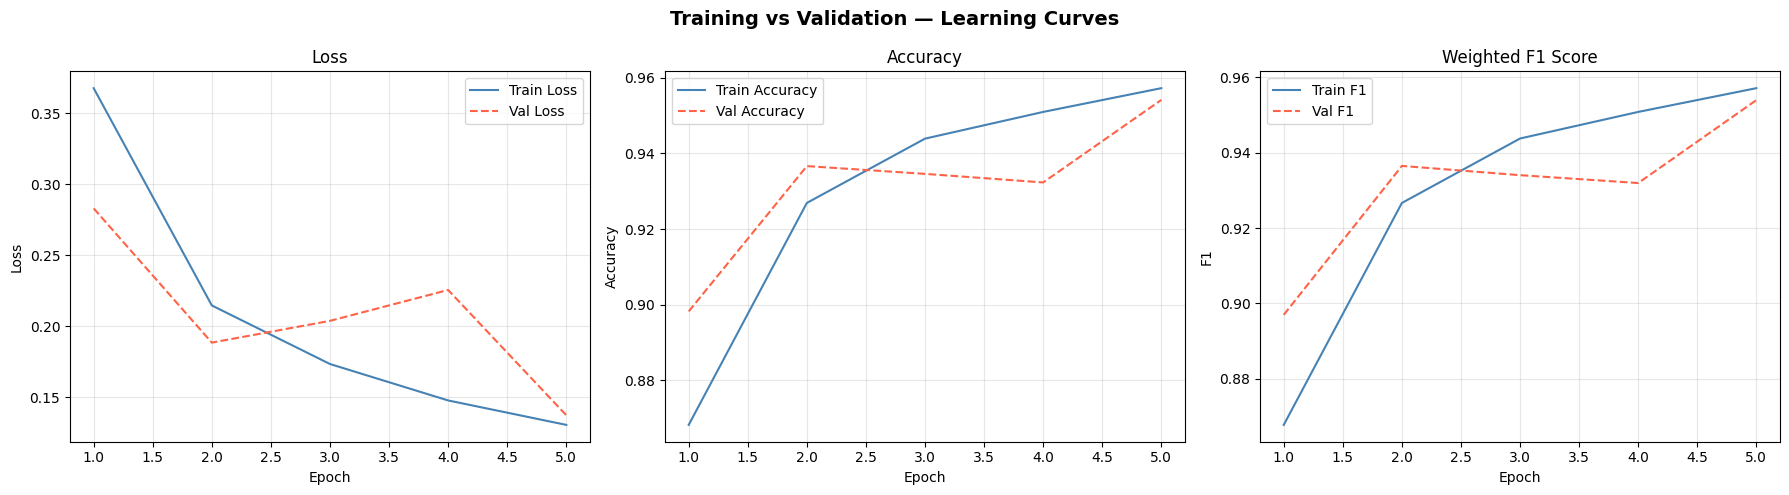

Saved: training_curves.png


In [ ]:
epochs_ran = len(history['loss'])
x_axis     = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(x_axis, history['loss'],     label='Train Loss',    color='steelblue')
axes[0].plot(x_axis, history['val_loss'], label='Val Loss',      color='tomato', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x_axis, history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(x_axis, history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(x_axis, history['f1'],     label='Train F1', color='steelblue')
axes[2].plot(x_axis, history['val_f1'], label='Val F1',   color='tomato', linestyle='--')
axes[2].set_title('Weighted F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

---
# **_▞▞ Evaluation on Test Set ▞▞_**
---

In [ ]:
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for batch_X, batch_y in tqdm(test_loader, desc="Evaluating on test set"):
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        test_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        test_labels.extend(batch_y.numpy())

test_acc  = accuracy_score(test_labels, test_preds)
test_f1   = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
test_prec = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
test_rec  = recall_score(test_labels, test_preds, average='weighted', zero_division=0)

print("="*55)
print(f"  TEST SET RESULTS")
print("="*55)
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall   : {test_rec:.4f}")
print("="*55)

Evaluating on test set:   0%|          | 0/138 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating on test set:   3%|▎         | 4/138 [00:22<12:25,  5.57s/it]


KeyboardInterrupt: 

---
# **_▞▞ Classification Report ▞▞_**

Shows per-class precision, recall and F1. This is the best way to see which arrhythmia types the model struggles with.

---

In [ ]:
# Only include classes that actually appear in the test set
present_classes = sorted(set(test_labels))
present_names   = [CLASS_NAMES[i] for i in present_classes]

print(classification_report(
    test_labels, test_preds,
    labels=present_classes,
    target_names=present_names,
    zero_division=0
))

              precision    recall  f1-score   support

          SR       0.00      0.00      0.00        44
        AFIB       0.00      0.00      0.00        31
       STACH       0.20      1.00      0.33        25
       SBRAD       0.00      0.00      0.00        28

    accuracy                           0.20       128
   macro avg       0.05      0.25      0.08       128
weighted avg       0.04      0.20      0.06       128



---
# **_▞▞ Confusion Matrix ▞▞_**

Each row = the true class. Each column = what the model predicted.
A perfect model would have all values on the diagonal.
Off-diagonal values tell you which classes are being confused with each other.

---

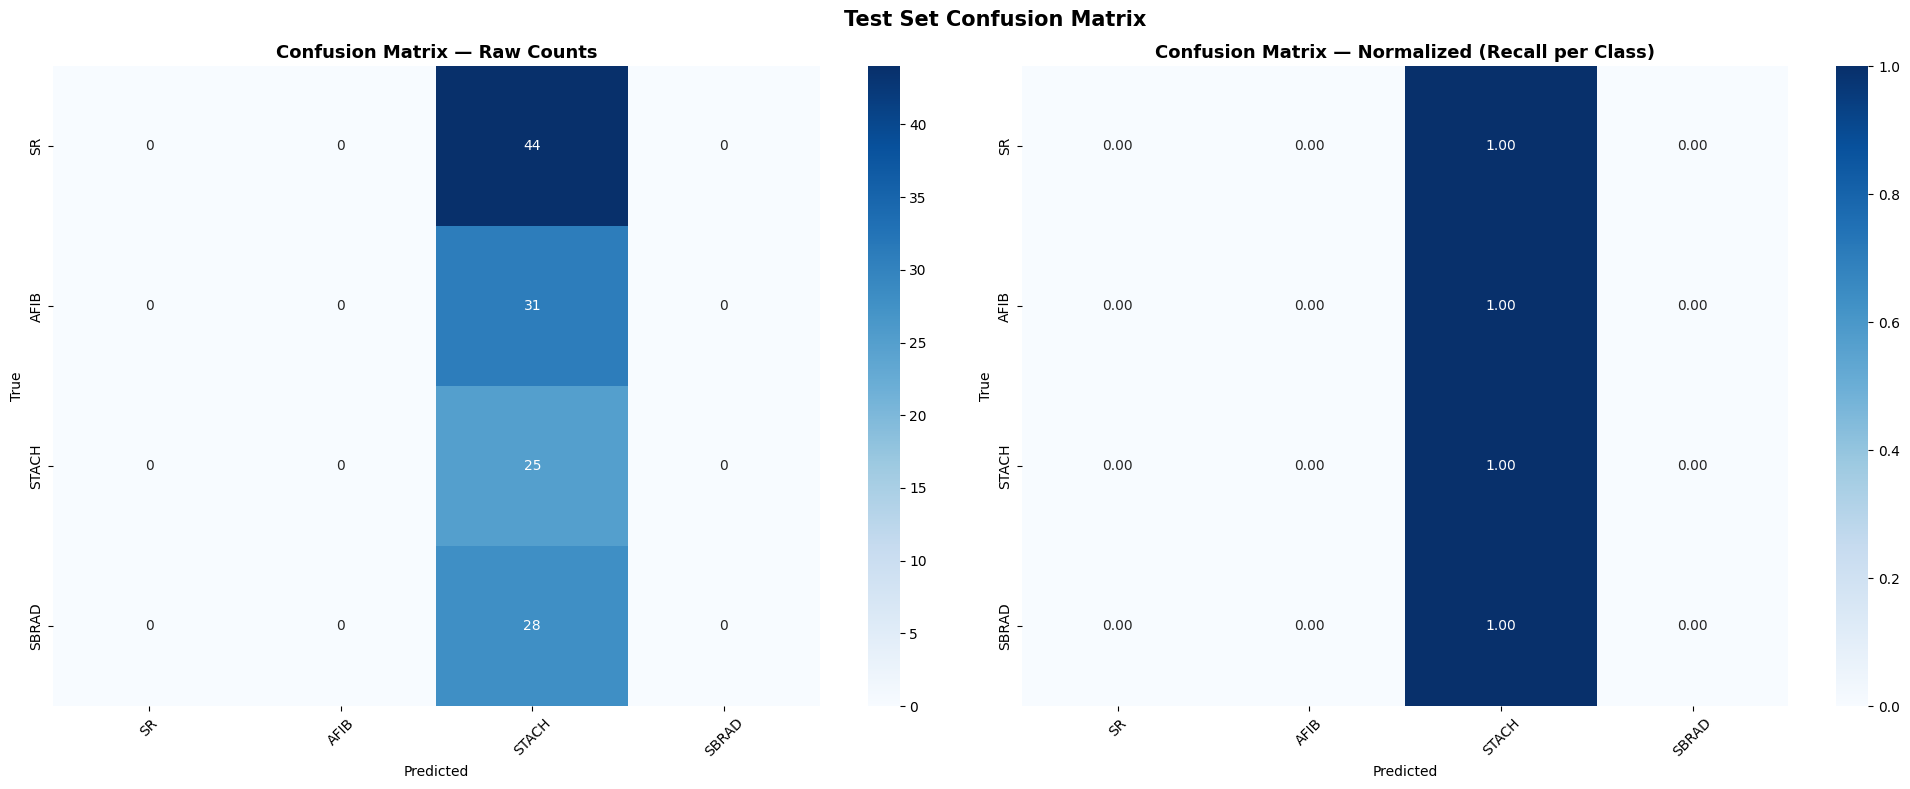

Saved: confusion_matrix.png


In [ ]:
cm = confusion_matrix(test_labels, test_preds, labels=present_classes)

# Normalize by row (true labels) so each row sums to 1
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Raw counts ────────────────────────────────────────────────────────
sns.heatmap(
    cm, ax=axes[0],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# ── Normalized (recall per class) ─────────────────────────────────────
sns.heatmap(
    cm_normalized, ax=axes[1],
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix — Normalized (Recall per Class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Test Set Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

---
# **_▞▞ Per-Class F1 Bar Chart ▞▞_**

A quick visual to identify which arrhythmia types are hardest to classify.

---

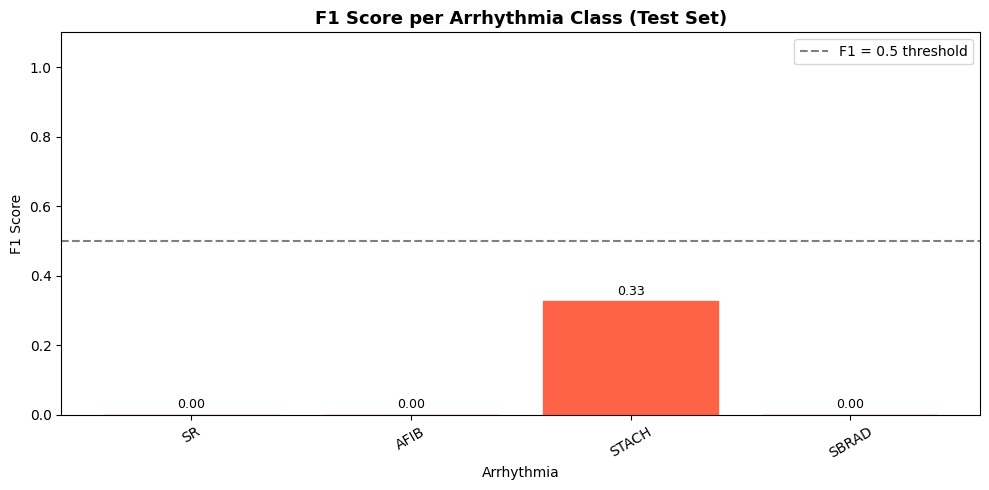

Saved: f1_per_class.png


In [ ]:
f1_per_class = f1_score(test_labels, test_preds, labels=present_classes, average=None, zero_division=0)

plt.figure(figsize=(10, 5))
bars = plt.bar(present_names, f1_per_class, color='steelblue', edgecolor='white')

# Color bars below 0.5 in red to highlight problem classes
for bar, score in zip(bars, f1_per_class):
    bar.set_color('tomato' if score < 0.5 else 'steelblue')
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2f}', ha='center', va='bottom', fontsize=9)

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='F1 = 0.5 threshold')
plt.title('F1 Score per Arrhythmia Class (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Arrhythmia')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f1_per_class.png")

---
# **_▞▞ Class Distribution Plot ▞▞_**

Visualize how balanced (or imbalanced) the dataset is after downsampling SR.

---

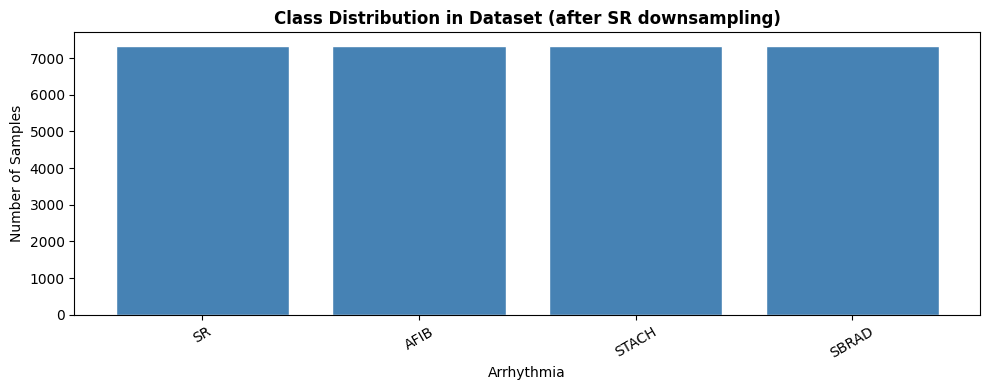

In [ ]:
dist = dataset.df['target'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar([CLASS_NAMES[i] for i in dist.index], dist.values, color='steelblue', edgecolor='white')
plt.title('Class Distribution in Dataset (after SR downsampling)', fontsize=12, fontweight='bold')
plt.xlabel('Arrhythmia')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# **_▞▞ Save Model ▞▞_**
---

In [ ]:
# Save the trained weights to your project folder


save_path = '/content/drive/MyDrive/TESIS-V2/Results/ecg_arrhythmia_model_v4m.pt'
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/TESIS-V2/Results/ecg_arrhythmia_model_v3.pt


In [ ]:
history_path = '/content/drive/MyDrive/TESIS-V2/Results/ecg_arrhythmia_model_v4m_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f)

---
# **_▞▞ Load Model ▞▞_**
---

In [ ]:
# Either map to your current device:
#model.load_state_dict(torch.load(save_path, weights_only=True, map_location=device))

# Or explicitly map to CPU:
#model.load_state_dict(torch.load(save_path, weights_only=True, map_location=torch.device('cpu')))

<All keys matched successfully>

In [ ]:
#load
#save_path = '/content/drive/MyDrive/TESIS-V2/Results/ecg_arrhythmia_model_v3.pt'
#model = ResNet1D(n_leads=N_LEADS, n_classes=OUTFEAT).to(device)
#model.load_state_dict(torch.load(save_path, weights_only=True))
model.eval()

ResNet1D(
  (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReL

In [ ]:
#history_path = '/content/drive/MyDrive/TESIS-V2/Results/ecg_arrhythmia_model_v3_history.json'
#with open(history_path, 'r') as f:
#    history = json.load(f)


#print(f"History loaded — {len(history['loss'])} epochs of data found.")

History loaded — 5 epochs of data found.


---
# **_▞▞ Single File Inference ▞▞_**

Run inference on a single `.dat` or `.mat` file. Set `inference_lead` to a number (0–11) to use only that lead, or `None` to use all 12.

---

In [ ]:
inference_lead    = LEAD_INDEX
single_file_path  = '/content/drive/MyDrive/TESIS-V2/Data/ptb-xl-1.0.3/records100/00000/00003_lr.dat'

# --- Load file based on extension ─────────────────────────────────────
ext = os.path.splitext(single_file_path)[-1].lower()

if ext == '.dat':
    with open(single_file_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=np.int16)
    n_samples = len(raw_data) // 12
    raw_data  = raw_data[:n_samples * 12].reshape(n_samples, 12).astype(np.float32) / 1000.0

elif ext == '.mat':
    mat = scipy.io.loadmat(single_file_path)

    # .mat files from different datasets use different key names —
    # this tries the most common ones automatically
    possible_keys = ['val', 'data', 'signal', 'ECG', 'ecg']
    raw_data      = None
    for key in possible_keys:
        if key in mat:
            raw_data = mat[key].astype(np.float32)
            break

    if raw_data is None:
        # Show available keys so you can identify the right one
        available = [k for k in mat.keys() if not k.startswith('_')]
        raise KeyError(f"Could not find ECG data in .mat file. Available keys: {available}")

    # .mat files are usually shaped (12, N) already — normalize if needed
    if raw_data.shape[0] == 12:
        raw_data = raw_data.T          # → (N, 12)
    elif raw_data.shape[1] != 12:
        raise ValueError(f"Unexpected .mat shape: {raw_data.shape}. Expected (12, N) or (N, 12).")

    # Normalize amplitude if values look like raw ADC counts (not millivolts)
    if np.abs(raw_data).max() > 10:
        raw_data = raw_data / 1000.0

else:
    raise ValueError(f"Unsupported file format: '{ext}'. Expected .dat or .mat")

# ── Normalize length to 1000 samples (same as training) ──────────────
n_samples = raw_data.shape[0]
if n_samples >= 1000:
    raw_data = raw_data[:1000, :]
else:
    pad      = np.zeros((1000 - n_samples, 12), dtype=np.float32)
    raw_data = np.vstack([raw_data, pad])

# ── Prepare tensor ────────────────────────────────────────────────────
x = torch.tensor(raw_data).T          # (12, 1000)

if inference_lead is not None:
    x = x[inference_lead].unsqueeze(0) # (1, 1000)

x_input = x.unsqueeze(0).to(device)   # (1, leads, 1000)

# ── Run inference ─────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    logits   = model(x_input)
    probs    = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred_cls = probs.argmax()

print(f"Predicted arrhythmia: {CLASS_NAMES[pred_cls]} (class {pred_cls})")
print("\nClass probabilities:")
for i, (name, prob) in enumerate(zip(CLASS_NAMES, probs)):
    bar = '█' * int(prob * 40)
    print(f"  {name:6s}: {prob:.4f}  {bar}")

Predicted arrhythmia: SBRAD (class 3)

Class probabilities:
  SR    : 0.0011  
  AFIB  : 0.0054  
  STACH : 0.0003  
  SBRAD : 0.9931  ███████████████████████████████████████


---

# **_▞▞ end of revision portion ▞▞_**
---



In [ ]:
import pandas as pd
import os
import torch
import torch.nn.functional as F
import numpy as np
import scipy.io

inference_lead = LEAD_INDEX

# Put the path to the file you want to test here (can be .pt, .mat, or .dat)
single_file_path = '/content/drive/MyDrive/TESIS-V2/Data/Processed_Tensors/JS07073.pt'

# Point this to your active CSV dataset map
csv_path = '/content/drive/MyDrive/TESIS-V2/Data/tensor_dataset_v3.csv' # or model_colab_ready_dataset.csv

# ── 1. Look up the ACTUAL Arrhythmia from the CSV ────────────────────────
# Get just the base name without any extension (e.g., '16115_lr')
base_filename = os.path.basename(single_file_path).replace('.pt', '').replace('.mat', '').replace('.dat', '')

try:
    df = pd.read_csv(csv_path)

    # Search for the base name in both possible path columns
    if 'tensor_path' in df.columns:
        match = df[df['tensor_path'].str.contains(base_filename, na=False)]
    else:
        match = df[df['file_path'].str.contains(base_filename, na=False)]

    if not match.empty:
        true_label = match.iloc[0]['primary_label']
        print("========================================")
        print(f" ACTUAL ARRHYTHMIA (Ground Truth): {true_label}")
        print("========================================\n")
    else:
        print(f"⚠️ Warning: '{base_filename}' is not in the CSV.")
        print("   (This is normal if it was dropped during dataset balancing!)\n")
except Exception as e:
    print(f"⚠️ Could not load CSV for ground truth verification: {e}\n")


# ── 2. Load file based on extension ─────────────────────────────────────
ext = os.path.splitext(single_file_path)[-1].lower()

if ext == '.pt':
    # Load the pre-processed tensor directly
    x = torch.load(single_file_path, weights_only=True)

elif ext == '.dat':
    with open(single_file_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=np.int16)
    n_samples = len(raw_data) // 12
    raw_data  = raw_data[:n_samples * 12].reshape(n_samples, 12).astype(np.float32) / 1000.0

    # Normalize length
    if raw_data.shape[0] >= 1000:
        raw_data = raw_data[:1000, :]
    else:
        pad = np.zeros((1000 - raw_data.shape[0], 12), dtype=np.float32)
        raw_data = np.vstack([raw_data, pad])

    x = torch.tensor(raw_data).T

elif ext == '.mat':
    mat = scipy.io.loadmat(single_file_path)
    possible_keys = ['val', 'data', 'signal', 'ECG', 'ecg']
    raw_data = None

    for key in possible_keys:
        if key in mat:
            raw_data = mat[key].astype(np.float32)
            break

    if raw_data is None:
        raise KeyError("Could not find ECG data in .mat file.")

    if raw_data.shape[0] == 12:
        raw_data = raw_data.T

    if np.abs(raw_data).max() > 10:
        raw_data = raw_data / 1000.0

    # Normalize length
    n_samples = raw_data.shape[0]
    if n_samples >= 1000:
        raw_data = raw_data[:1000, :]
    else:
        pad = np.zeros((1000 - n_samples, 12), dtype=np.float32)
        raw_data = np.vstack([raw_data, pad])

    x = torch.tensor(raw_data).T
else:
    raise ValueError(f"Unsupported file format: '{ext}'. Expected .pt, .dat, or .mat")

# ── 3. Prepare tensor ───────────────────────────────────────────────────
if inference_lead is not None:
    x = x[inference_lead].unsqueeze(0) # (1, 1000)

x_input = x.unsqueeze(0).to(device)   # (1, leads, 1000)

# ── 4. Run inference ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    logits   = model(x_input)
    probs    = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred_cls = probs.argmax()

print(f"PREDICTED ARRHYTHMIA: {CLASS_NAMES[pred_cls]} (class {pred_cls})")
print("\nClass probabilities:")
for i, (name, prob) in enumerate(zip(CLASS_NAMES, probs)):
    bar = '█' * int(prob * 40)
    print(f"  {name:6s}: {prob:.4f}  {bar}")

 ACTUAL ARRHYTHMIA (Ground Truth): AFIB

PREDICTED ARRHYTHMIA: AFIB (class 1)

Class probabilities:
  SR    : 0.0001  
  AFIB  : 0.9960  ███████████████████████████████████████
  STACH : 0.0039  
  SBRAD : 0.0001  


---

# **_▞▞ image to tensor prediction ▞▞_**
---



In [ ]:

IMAGE_PATH = '/content/drive/MyDrive/TESIS-V2/sbrad.png'

In [ ]:
# ── Guard: make sure Pillow is installed (pre-installed on Colab, safe to run) ─
import importlib, subprocess, sys
if importlib.util.find_spec('PIL') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'Pillow'])

# ── Imports ──────────────────────────────────────────────────────────────────
import os
import numpy as np
import torch
import torch.nn.functional as F
from PIL   import Image
from scipy.signal import resample

# ── Configuration — ONLY these two lines normally need changing ───────────────

# Path to your ECG image.
#   Option A: set after using the upload cell above  →  IMAGE_PATH is already set
#   Option B: Google Drive path, e.g.:
# IMAGE_PATH = '/content/drive/MyDrive/TESIS-V2/ecg_sample.png'

# Uncomment and edit the line below only if you did NOT use the upload cell:
# IMAGE_PATH = '/content/ecg_sample.png'

# How to fill missing channels when fewer than 12 leads are detected:
#   'repeat' → cycle the detected leads  (recommended for single-strip images)
#   'zero'   → pad with flat-zero signals
LEAD_FILL_STRATEGY = 'repeat'

# Uses the LEAD_INDEX value defined at the top of your notebook.
# None = all 12 channels fed to the model; 0-11 = single channel.
INFERENCE_LEAD = LEAD_INDEX


# ════════════════════════════════════════════════════════════════════════════
#  INTERNAL HELPERS  (no changes needed below this line)
# ════════════════════════════════════════════════════════════════════════════

def _detect_trace_likelihood(arr_rgb):
    """
    Return a (H, W) float array where high values mark likely trace pixels.

    Strategy
    --------
    1. Estimate background colour from image corners/edges.
    2. Compute per-pixel distance from background.
    3. If the trace is a saturated colour (red/blue/green), use a colour-
       channel difference map so axis labels and gridlines (which are grey
       or black) don't interfere.
    4. For dark/black traces on a light background, use inverse brightness.
    """
    H, W = arr_rgb.shape[:2]

    # ── Background estimation ────────────────────────────────────────────────
    # Sample the four corners + midpoints of each edge
    edge_samples = np.concatenate([
        arr_rgb[ :H//8,    :W//8].reshape(-1, 3),   # top-left
        arr_rgb[ :H//8,  -W//8:].reshape(-1, 3),   # top-right
        arr_rgb[-H//8:,   :W//8].reshape(-1, 3),   # bottom-left
        arr_rgb[-H//8:, -W//8:].reshape(-1, 3),   # bottom-right
    ], axis=0)
    bg = np.median(edge_samples, axis=0)           # robust background colour

    # ── Colour-channel trace detection ──────────────────────────────────────
    r, g, b = arr_rgb[:,:,0], arr_rgb[:,:,1], arr_rgb[:,:,2]

    # How much each channel deviates from the background in a non-neutral way
    # Positive = that channel is MORE prominent than the other two
    redness   = np.clip(r - np.maximum(g, b), 0, None)   # red trace
    blueness  = np.clip(b - np.maximum(r, g), 0, None)   # blue trace
    greenness = np.clip(g - np.maximum(r, b), 0, None)   # green trace

    colour_signal = np.stack([redness, blueness, greenness], axis=0)
    best_colour   = colour_signal.max(axis=0)             # strongest colour trace
    best_colour_v = best_colour.max()                     # peak value

    # ── Dark/black trace on light background ────────────────────────────────
    darkness = bg.mean() - arr_rgb.mean(axis=2)           # how much darker than bg
    darkness = np.clip(darkness, 0, None)
    darkness_v = darkness.max()

    # Choose whichever signal is stronger across the whole image
    if best_colour_v > darkness_v * 0.5:
        return best_colour   # coloured trace
    else:
        return darkness      # dark/black trace


def _find_lead_bands(likelihood, margin=0.12):
    """
    Return (y_start, y_end) for each horizontal ECG strip row.

    Uses the per-row maximum of the trace likelihood map: rows that
    contain at least one likely trace pixel are 'active'.  Contiguous
    active runs are merged into bands.
    """
    H = likelihood.shape[0]
    row_activity = likelihood.max(axis=1)                  # (H,)

    # Smooth over ~1 % of image height
    k = max(1, int(H * 0.01))
    row_smooth = np.convolve(row_activity, np.ones(k) / k, mode='same')

    threshold = row_smooth.max() * margin
    active    = row_smooth > threshold

    bands, in_band, start = [], False, 0
    for i, val in enumerate(active):
        if val and not in_band:
            start, in_band = i, True
        elif not val and in_band:
            bands.append((start, i))
            in_band = False
    if in_band:
        bands.append((start, H))

    min_h = max(4, H * 0.015)
    return [(s, e) for s, e in bands if (e - s) >= min_h]


def _extract_waveform(patch_likelihood):
    """
    From a 2-D likelihood patch (one ECG strip), extract the 1-D waveform.

    For each column x, compute the brightness-weighted centroid of pixels
    above 40 % of the column maximum.  Missing columns (no trace pixels)
    are filled by linear interpolation.
    """
    strip_H, W = patch_likelihood.shape
    signal    = np.zeros(W, dtype=np.float32)
    has_trace = np.zeros(W, dtype=bool)

    for x in range(W):
        col = patch_likelihood[:, x]
        col_max = col.max()
        if col_max < 0.05:                       # below noise floor → skip
            continue
        thr      = col_max * 0.4
        active_y = np.where(col >= thr)[0]
        if len(active_y) > 0:
            weights       = col[active_y]
            signal[x]     = (active_y * weights).sum() / weights.sum()
            has_trace[x]  = True

    # Interpolate any columns where no trace was found
    if has_trace.sum() < W:
        xs       = np.arange(W)
        xs_valid = xs[has_trace]
        if len(xs_valid) >= 2:
            signal = np.interp(xs, xs_valid, signal[has_trace]).astype(np.float32)
        # else: entire strip is blank → signal stays zero

    # Flip so upward deflection in the image = positive amplitude (ECG convention)
    signal = (strip_H - 1) - signal
    signal -= signal.mean()                      # remove DC offset
    return signal


def image_to_ecg_tensor(image_path,
                         target_samples=1000,
                         n_leads_out=12,
                         fill_strategy='repeat'):
    """
    Convert an ECG image (JPEG / PNG / TIFF …) to a model-ready tensor.

    Handles
    -------
    • Coloured traces — red, blue, green (e.g. matplotlib exports)
    • Dark / black traces on a light background (scanned ECG printouts)
    • Single-lead strips and multi-lead 12-row printouts
    • Axis decorations, tick marks, and gridlines are automatically ignored

    Parameters
    ----------
    image_path     : str   path to the ECG image
    target_samples : int   time-steps the model expects (default 1000)
    n_leads_out    : int   number of output channels    (default 12)
    fill_strategy  : str   'repeat' or 'zero' for missing channels

    Returns
    -------
    tensor  : torch.FloatTensor  shape (n_leads_out, target_samples)
    n_found : int                lead strips detected in the image
    """
    if not os.path.isfile(image_path):
        raise FileNotFoundError(
            f"Image not found: {image_path}\n"
            "Tip: use the upload cell above to put the file in /content/, "
            "or check your Google Drive path."
        )

    img  = Image.open(image_path).convert('RGB')
    arr  = np.array(img, dtype=np.float32) / 255.0   # (H, W, 3)  range [0,1]

    likelihood = _detect_trace_likelihood(arr)        # (H, W)
    bands      = _find_lead_bands(likelihood)         # list of (y0, y1)

    n_found = len(bands)
    if n_found == 0:
        raise ValueError(
            "No ECG trace was detected in the image.\n"
            "Tips:\n"
            "  • Use a clear ECG image with a light/white background.\n"
            "  • Increase the image resolution or contrast.\n"
            "  • Try a different colour format (e.g. export as PNG instead of JPEG)."
        )

    raw_leads = []
    for (y0, y1) in bands:
        signal = _extract_waveform(likelihood[y0:y1, :])

        # Resample to target_samples
        signal = resample(signal, target_samples).astype(np.float32)

        # Z-score normalise so amplitude matches training distribution
        std = signal.std()
        if std > 1e-6:
            signal = (signal - signal.mean()) / std

        raw_leads.append(signal)

    # ── Fill / truncate to exactly n_leads_out channels ──────────────────────
    leads_out = []
    for i in range(n_leads_out):
        if i < n_found:
            leads_out.append(raw_leads[i])
        elif fill_strategy == 'repeat':
            leads_out.append(raw_leads[i % n_found].copy())
        else:
            leads_out.append(np.zeros(target_samples, dtype=np.float32))

    tensor = torch.tensor(np.stack(leads_out, axis=0))   # (n_leads_out, 1000)
    return tensor, n_found


# ── Run inference ─────────────────────────────────────────────────────────────

print('=' * 55)
print('  ECG IMAGE INFERENCE')
print('=' * 55)
print(f'  Image              : {IMAGE_PATH}')
print(f'  Lead fill strategy : {LEAD_FILL_STRATEGY}')
print()

# 1. Image → (12, 1000) tensor
x, n_detected = image_to_ecg_tensor(
    IMAGE_PATH,
    target_samples=1000,
    n_leads_out=12,
    fill_strategy=LEAD_FILL_STRATEGY,
)

print(f'  Lead strips detected : {n_detected}')
if n_detected < 12:
    fill_note = ('cycled from detected leads'
                 if LEAD_FILL_STRATEGY == 'repeat' else 'set to zero')
    print(f'  ⚠  {12 - n_detected} missing channel(s) were {fill_note}')
print(f'  Tensor shape         : {tuple(x.shape)}  (leads × samples)')
print()

# 2. Optionally select a single lead (mirrors LEAD_INDEX at the top of your notebook)
if INFERENCE_LEAD is not None:
    x = x[INFERENCE_LEAD].unsqueeze(0)   # (1, 1000)

x_input = x.unsqueeze(0).to(device)      # (1, leads, 1000)

# 3. Model forward pass
model.eval()
with torch.no_grad():
    logits   = model(x_input)
    probs    = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred_cls = int(probs.argmax())

# 4. Display results
print(f'  PREDICTED ARRHYTHMIA : {CLASS_NAMES[pred_cls]}  (class {pred_cls})')
print(f'  Confidence           : {probs[pred_cls] * 100:.1f} %')
print()
print('  Class probabilities:')
for name, prob in zip(CLASS_NAMES, probs):
    bar = '█' * int(prob * 40)
    print(f'    {name:6s}  {prob:.4f}  {bar}')
print()
print('  ─── Accuracy note ───────────────────────────────────────')
print('  Image-derived signals are approximate.  Results are most')
print('  reliable when the image is a clean, high-resolution ECG')
print('  with a plain white background and a single trace colour.')
print('  For clinical use, prefer .dat / .mat numerical files.')
print('=' * 55)


  ECG IMAGE INFERENCE
  Image              : /content/drive/MyDrive/TESIS-V2/ex3.png
  Lead fill strategy : repeat

  Lead strips detected : 1
  ⚠  11 missing channel(s) were cycled from detected leads
  Tensor shape         : (12, 1000)  (leads × samples)

  PREDICTED ARRHYTHMIA : AFIB  (class 1)
  Confidence           : 100.0 %

  Class probabilities:
    SR      0.0000  
    AFIB    1.0000  ███████████████████████████████████████
    STACH   0.0000  
    SBRAD   0.0000  

  ─── Accuracy note ───────────────────────────────────────
  Image-derived signals are approximate.  Results are most
  reliable when the image is a clean, high-resolution ECG
  with a plain white background and a single trace colour.
  For clinical use, prefer .dat / .mat numerical files.
